Plot saved to dft2_ode_check.png


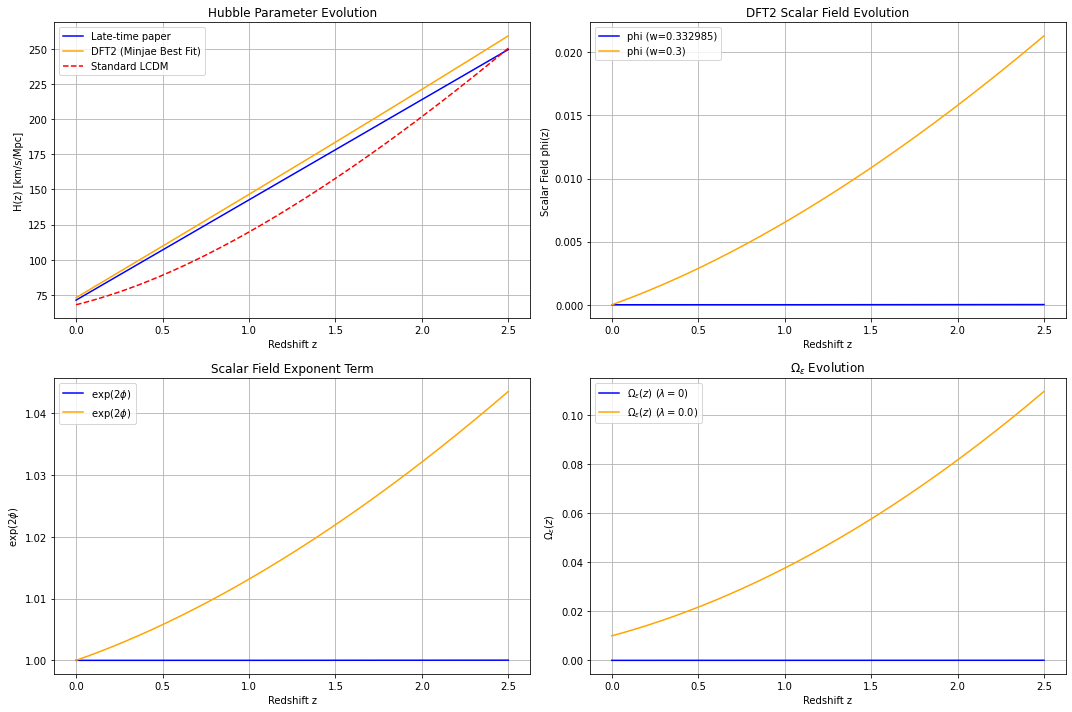

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import scipy.integrate as sp_int

# ==========================================
# 1. ODE Functions (Copied from DFT2Cosmology.py)
# ==========================================

@njit(cache=True)
def RHS_numba(z, y, h, Ok, Oh, OL, Oe, w, l):
    phi = y[0]
    H = y[1]
    
    if H <= 0.0:
        H = h * 100.0

    OeEvol1 = 6.0 * (w + 1.0) / (l + 2.0)
    # Clamp phi to prevent overflow in exp()
    if phi > 50.0:
        phi_clamped = 50.0
    elif phi < -50.0:
        phi_clamped = -50.0
    else:
        phi_clamped = phi
        
    OeEvol2 = np.exp(4.0 * phi_clamped / (l + 2.0)) 
    
    H_sq = H**2.0
    inSqrt = 3.0 / (h * 100.0)**2.0 + (
        6.0 * Oe * (1.0 + z)**OeEvol1 * OeEvol2
        + 6.0 * OL
        + 6.0 * Ok * (1.0 + z)**2.0
        + 6.0 * Oh * (1.0 + z)**6.0
    ) / H_sq
    
    if not inSqrt < 0.0:
        dphidz   = -1.0 * (3 - (h * 100.0) * inSqrt**0.5) / (2.0 * (1.0 + z))
        dHdz = -(h * 100.0)**2.0 * (
            (
                3.0 * w * Oe * (1.0 + z)**OeEvol1 * OeEvol2
                + 2.0 * Ok * (1.0 + z)**2.0
                + 6.0 * Oh * (1.0 + z)**6.0
            ) / H
            - H / (h * 100.0) * inSqrt**0.5
        ) / (1.0 + z)
    else:
        dphidz = -1.0
        dHdz   = -1.0
    
    return np.array([dphidz, dHdz])

@njit(cache=True)
def solve_ode_numba(y0, z_start, z_end, steps, h, Ok, Oh, OL, Oe, w, l):
    z_vals = np.linspace(z_start, z_end, steps)
    dz = z_vals[1] - z_vals[0]
    
    y_vals = np.zeros((steps, 2))
    y_vals[0] = y0
    
    y = y0.copy()
    
    for i in range(steps - 1):
        z = z_vals[i]
        
        k1 = RHS_numba(z, y, h, Ok, Oh, OL, Oe, w, l)
        k2 = RHS_numba(z + 0.5*dz, y + 0.5*dz*k1, h, Ok, Oh, OL, Oe, w, l)
        k3 = RHS_numba(z + 0.5*dz, y + 0.5*dz*k2, h, Ok, Oh, OL, Oe, w, l)
        k4 = RHS_numba(z + dz, y + dz*k3, h, Ok, Oh, OL, Oe, w, l)
        
        y = y + (dz/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        y_vals[i+1] = y
        
    return z_vals, y_vals

# ==========================================
# 2. Main Script for Manual Checking
# ==========================================

def run_dft2_model(h_val, Ok_val, Oh_val, OL_val, Oe_val, w_val, l_val):
    """Solve ODE for DFT2 model"""
    z_max = 2.5
    steps = 1000
    y0 = np.array([0.0, h_val * 100.0])
    
    z_out, y_out = solve_ode_numba(
        y0, 0.0, z_max, steps,
        h_val, Ok_val, Oh_val, OL_val, Oe_val, w_val, l_val
    )
    
    phi_out = y_out[:, 0]
    H_out = y_out[:, 1]
    
    return z_out, phi_out, H_out

def get_lcdm_h(z_array, h, Om, OL, Ok):
    """Analytical H(z) for standard LCDM"""
    # H(z) = H0 * sqrt(Om(1+z)^3 + Ok(1+z)^2 + OL)
    # H0 = 100 * h
    H0 = 100.0 * h
    E_sq = Om * (1 + z_array)**3 + Ok * (1 + z_array)**2 + OL
    return H0 * np.sqrt(E_sq)

if __name__ == "__main__":
    # --- 1. DFT2 Model Parameters (Minjae Chain Best Fit) ---
    dft_params1 = {
        'h': 0.7129,
        'Ok': 0.999997,
        'Oh': 1/12 * (0.000348)**2,
        'OL': -0.000013,
        'Oe': 0.000003,
        'w': 0.332985,
        'l': 0,
        'label': 'Late-time paper'
    }

    dft_params2 = {
        'h': 0.7304,
        'Ok': 0.9999,
        'Oh': 0.0000001,
        'OL': -0.0001,
        'Oe': 0.01,
        'w':  0.3,
        'l':  0.0,
        'label': 'DFT2 (Minjae Best Fit)'
    }

    # --- 2. Standard LCDM Parameters (Reference) ---
    # Standard Flat LCDM: Om=0.3, OL=0.7, h=0.7
    lcdm_params = {
        'h': 0.68,
        'Om': 0.3,
        'OL': 0.7,
        'Ok': 0,
        'label': 'Standard LCDM'
    }

    # Run DFT2 Simulation
    z_dft, phi_dft1, H_dft1 = run_dft2_model(
        dft_params1['h'], dft_params1['Ok'], dft_params1['Oh'], 
        dft_params1['OL'], dft_params1['Oe'], dft_params1['w'], dft_params1['l']
    )
    z_dft, phi_dft2, H_dft2 = run_dft2_model(
        dft_params2['h'], dft_params2['Ok'], dft_params2['Oh'], 
        dft_params2['OL'], dft_params2['Oe'], dft_params2['w'], dft_params2['l']
    )
    
    # Calculate LCDM Analytical H(z)
    # Use same z array as DFT for easy plotting
    H_lcdm = get_lcdm_h(z_dft, lcdm_params['h'], lcdm_params['Om'], lcdm_params['OL'], lcdm_params['Ok'])
    
    # --- Plotting ---
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: H(z) Comparison
    ax1.plot(z_dft, H_dft1, label=dft_params1['label'], color='blue')
    ax1.plot(z_dft, H_dft2, label=dft_params2['label'], color='orange')
    ax1.plot(z_dft, H_lcdm, label=lcdm_params['label'], color='red', linestyle='--')
    
    ax1.set_xlabel('Redshift z')
    ax1.set_ylabel('H(z) [km/s/Mpc]')
    ax1.set_title('Hubble Parameter Evolution')
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2: Scalar Field phi(z) (DFT2 only)
    ax2.plot(z_dft, phi_dft1, label=f"phi (w={dft_params1['w']})", color='blue')
    ax2.plot(z_dft, phi_dft2, label=f"phi (w={dft_params2['w']})", color='orange')
    
    ax2.set_xlabel('Redshift z')
    ax2.set_ylabel('Scalar Field phi(z)')
    ax2.set_title('DFT2 Scalar Field Evolution')
    ax2.legend()
    ax2.grid(True)

    # Plot 3: exp(2*phi) (DFT2 only)
    # Clamp inputs purely for safe plotting visualization similarly to model logic
    phi_clamped1 = np.clip(phi_dft1, -50, 50)
    exp_2phi1 = np.exp(2.0 * phi_clamped1)
    phi_clamped2 = np.clip(phi_dft2, -50, 50)
    exp_2phi2 = np.exp(2.0 * phi_clamped2)

    ax3.plot(z_dft, exp_2phi1, label=r'$\exp(2\phi)$', color='blue')
    ax3.plot(z_dft, exp_2phi2, label=r'$\exp(2\phi)$', color='orange')
    
    ax3.set_xlabel('Redshift z')
    ax3.set_ylabel(r'$\exp(2\phi)$')
    ax3.set_title('Scalar Field Exponent Term')
    ax3.legend()
    ax3.grid(True)
    
    # Plot 4: Omega_epsilon(z) with lambda=0
    # Formula: Oe(z) = (H0/H(z))^2 * Oe0 * (1+z)^(3(1+w)) * exp(2*phi)
    # Note: lambda=0 is assumed as requested.
    H0_dft1 = dft_params1['h'] * 100.0
    Oe01 = dft_params1['Oe']
    w_val1 = dft_params1['w']
    l_val1 = dft_params1['l']
    
    # Avoid division by zero if H_dft has 0 (shouldn't happen for valid z)
    ratio_H1 = (H0_dft1 / H_dft1)**2
    term_z1 = (1.0 + z_dft)**(6.0 * (1.0 + w_val1) / (l_val1 + 2.0))
    
    Oe_z1 = ratio_H1 * Oe01 * term_z1 * np.exp(4.0 * phi_clamped1 / (l_val1 + 2.0))
    
    H0_dft2 = dft_params2['h'] * 100.0
    Oe02 = dft_params2['Oe']
    w_val2 = dft_params2['w']
    l_val2 = dft_params2['l']
    
    # Avoid division by zero if H_dft has 0 (shouldn't happen for valid z)
    ratio_H2 = (H0_dft2 / H_dft2)**2
    term_z2 = (1.0 + z_dft)**(6.0 * (1.0 + w_val2) / (l_val2 + 2.0))
    
    Oe_z2 = ratio_H2 * Oe02 * term_z2 * np.exp(4.0 * phi_clamped2 / (l_val2 + 2.0))
    
    ax4.plot(z_dft, Oe_z1, label=r'$\Omega_{\varepsilon}(z)$ ($\lambda=$'+str(l_val1)+')', color='blue')
    ax4.plot(z_dft, Oe_z2, label=r'$\Omega_{\varepsilon}(z)$ ($\lambda=$'+str(l_val2)+')', color='orange')
    ax4.set_xlabel('Redshift z')
    ax4.set_ylabel(r'$\Omega_{\varepsilon}(z)$')
    ax4.set_title(r'$\Omega_{\varepsilon}$ Evolution')
    ax4.legend()
    ax4.grid(True)

    output_file = 'dft2_ode_check.png'
    plt.tight_layout()
    plt.savefig(output_file)
    print(f"Plot saved to {output_file}")
    plt.show()
